# 📊 First insight — NCAA cover rates by situation (2021–22)

**Question:** do favorites, home teams, and home underdogs cover the spread at the rate an
*efficient* market would imply?

Each cover rate is judged against two benchmarks:

- **50.0%** — an **unbiased** line (the spread is the right forecast, on average).
- **52.38%** — the **break-even** rate after the standard −110 vig (could you actually
  *profit*, not just spot a bias?).

The logic lives in `src/ncaa_market/analysis/cover_rates.py`; this notebook imports it and
visualizes the result. **Scope:** a single season (2021–22, ~5,400 games) — a first look,
not a final verdict.

In [1]:
# setup cell
import sys
from pathlib import Path

import matplotlib.pyplot as plt

root = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config" / "settings.yaml").exists()
)
sys.path.insert(0, str(root / "src"))

from ncaa_market.analysis.cover_rates import first_look  # noqa: E402

summary = first_look(2022)
summary

,split,n,cover_rate,ci_low,ci_high,sig_vs_50
0,All favorites,5177,0.480780,0.467189,0.494400,True
1,All home teams,5367,0.485933,0.472576,0.499310,True
2,Home underdogs,1538,0.507802,0.482828,0.532738,False
3,Home favorites,3639,0.475955,0.459762,0.492199,True
4,Road favorites,1538,0.492198,0.467262,0.517172,False


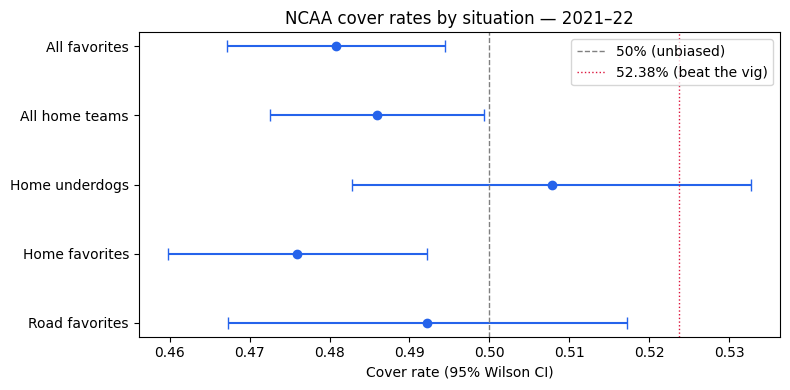

In [2]:
# chart cell — cover rate by situation with 95% CI, vs the two benchmarks
fig, ax = plt.subplots(figsize=(8, 4))
y = range(len(summary))
xerr = [summary["cover_rate"] - summary["ci_low"], summary["ci_high"] - summary["cover_rate"]]
ax.errorbar(summary["cover_rate"], y, xerr=xerr, fmt="o", capsize=4, color="#2563eb")
ax.set_yticks(list(y))
ax.set_yticklabels(summary["split"])
ax.invert_yaxis()
ax.axvline(0.50, color="gray", ls="--", lw=1, label="50% (unbiased)")
ax.axvline(0.5238, color="crimson", ls=":", lw=1, label="52.38% (beat the vig)")
ax.set_xlabel("Cover rate (95% Wilson CI)")
ax.set_title("NCAA cover rates by situation — 2021–22")
ax.legend()
plt.tight_layout()
plt.show()

## What it means

None of these strategies provide convincing evidence of profitability.


**Favorites were overpriced in 2021–22.** Favorites covered just **48.1%** (95% CI
[46.7%, 49.4%]) — the interval excludes 50%, so the bias is statistically real this season.
It's strongest for **home favorites (47.6%)** — the classic "favorite bias."

**But biased ≠ beatable.** Favorites at 48.1% means underdogs covered ~**51.9%** — above
50%, yet still **below the 52.38% break-even**. So the line was *mispriced* but not
*profitable* after the vig. That distinction — unbiasedness vs. exploitability — is the
whole point of this study.

**Home underdogs (50.8%)** lean the "undervalued" way, but the CI straddles 50%, so it's
not significant in a single season.

### Caveats
- **One season only.** Real edges are tiny (1–2%); a single season has limited statistical
  power. Firm conclusions wait for all 15 seasons (2008–2022).
- **Multiple, overlapping tests.** Five splits were checked and they overlap (favorites
  include home + road favorites). When we pool all seasons we'll apply a
  **Benjamini–Hochberg FDR correction** before calling anything "significant."
- **Persistence unknown.** A genuine inefficiency must recur *across seasons*, not just here.

### Next
Scale the pipeline to 2008–2022 and re-run these splits with proper multiple-comparison
control — then test whether the favorite bias actually *persists*.